# What is Git -- and why does it exist?

###  The problem that git solves : 
Imagine you are working a Python project. Things are going well. Then you change something and everything breaks. You wish you could go back to how it was yesterday. So you start doing this: 
`project_v1/ project_v2/ project_v2_final/ project_v2_final_REAL/ project_v2_final_REAL_2/`

This is what every developer does before discovering Git It is chaotic, wastes disk space, and becomes impossible to manage when multiple people are invloved.

`Git is the solution` -- It is a version control system -- software that tracks every change you make to your files, lets you name those changes, and lets you go back to any point in history instantly.


* `Git` -- A tool that runs a on your computer. It tracks file changes locally. Created by Linus Torvalds in 2005 for linuz kernel development. Open-source and free forever.

* `GitHub`-- A website where you can store your Git repositories in the cloud. Adds collaboration features: Pull Requests, Issues, Actions. Owned by Microsoft since 2018

#### Wht Git actually does :
Git stores your project as a series of snapshots called commits. Each commit is a complete picture of every file at that moment in time, along with a message describing what changed.

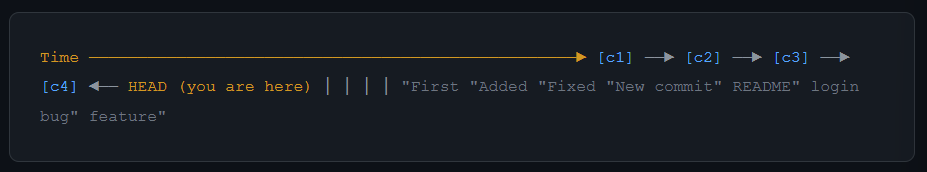


Key Vocabulary and Their meaning:

* `repository (repo)` -- Your project folder tracked by Git. Contains all your files and their full history.
* `commit` -- A saved snapshot Like pressing "save" in a vedio game -- you can always reload from here.
* `branch` -- A parallel version of your code. Work on new features here without affecting main code.
* `HEAD` -- A printer to "where you are right now" in the project history
* `remote` -- A copy of the repo stored elsewhere (like GitHub). Called "origin" by convention.
* `clone` -- Downloading a full copy of a remote repo to your computer.
* `push` -- Uploading your local commits to the remote(GitHub).

* `pull` -- Downloading commits from the remote into your local copy.



Why every developer uses Git:

- Never lose work:full history of every change.
- Experiment safely: branches let you try things without risk.
- Collaborate : Multiple people work on the same codebase without stepping on each other.
- Review Code: See exactly what changed and why.
- Revert mistakes: one command takes you back to any working state.
- Required for jobs: every tech company uses Git.


# GitHub First time configuration:

Git needs to know who you are because every commit is stamped with your name and email. This is global-- you only do it once per machine.

```Python
# Set your name(use your real name)

git config --global user.name "Dibya Joy"

# Set your email (use the same email as your GitHub account)
git config --global user.email "dibya@example.com"

# Set the default branch name to 'main' (modern standard)
git config --global init.defaultBranch main

# Set vs code as your default editor (optional but recomended)

git config --global core.editor "code --wait"

# Verify all settings 

git config --list

user.name=Dibya Joy
user.email=dibya@example.com
init.defaultBranch=main
```


# Daily Use of SSH key pair 

```Python

#Generate an SSH key pair
ssh-keygen -t ed25519 -c "dibya@example.com"

Press enter three times to accept defaults

#copy  your public key to clipboard

cat ~/.ssh/id_ed25519.pub

Then: GitHub -> Settings -> SSH and GPG keys -> New SSH key -> paste it

# Test the connection
ssh -T git@github.com

Hi DrChaos1999! You've successfully authenticated
```


# Some useful global settings

```Python
# Color output (make git status much easier to read)

# Better diff output
git config --global diff.colorMoved zebra

# Store credentials so you don't re-enter them

git config --global credentials.helper store

```


# Git's three zones:

Every file in a Git project exists in one of three places at any time. Mastering Git means understanding how to move files between these zones.


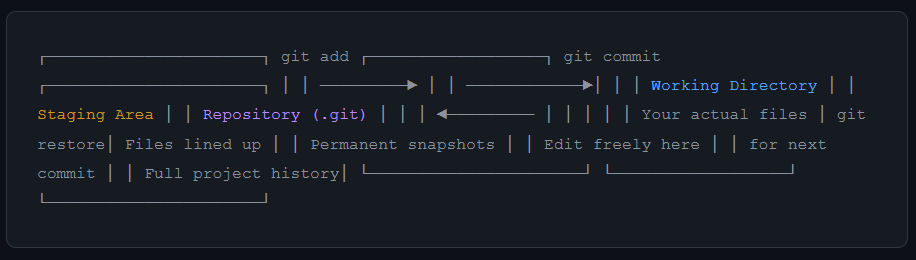 


# Working Directory 
The actual files on your disk. You edit normally. Git watches them but doesn't control them yet.

# Staging Area(Index)

A "ready to commit" queue You choose exactly which changes go into the next snapshot. Unique to Git-- most systems don't have this.

# Repository

The .git folder. Conatains your entire project history. Every commit ever made lives here permanently.

# Why does the staging area exist?
Suppose you fixed a bug in `app.py` and also started a new feature in `feature.py`. Without staging, a commit would include both. With staging, you can commit just the bug fix cleanly:


```Python

git add app.py          # stage only the bug fix
git commit -m "Fix login bug"

git add feature.py      # now stage the feature separately
git commit -m "Start new feature"

```

File stages in Git

Every file in your working directory is in one of these status:

- `Untrcked`-- A new file Git doesn't know about yet -- `git status` shows it in red.

- `Modified`--  An existing file that has changed since last commit -- `git status` shows it in green.
- `Stages`-- Marked for inclusion in the next commit. `git status`-- shows it in green.

- `Commited` -- Safely stored in the repository --  `git log` shows it.

- `Ignored`-- Explicitly excluded via `.gitignore`--- Not shown in status at all.



# The .gitignore file:

Some files should never be commited-- virtual environments, compiled files, API keys, `node_modules`. You tell git to ignore them by listing patterns in a file called `.gitignore` at the root of your project 

```Python 
# .gitignore --typical Python project

___pycache__/
*.pyc
.env      # Never commit API keys 
venv/
.vscode/
*.egg-info/
dist/
.DS_Store  # macOS junk
```


# Inside the .git folder 

When you run `git init`, Git creates a hidden `.git` folder. You never need to touch it directly, but knowing what's inside helps:

- `.git/HEAD` -- Points to your current branch/commit
- `.git/objects/` -- All your commits, files, and tree structures stored as compressed blobs.
- `.git/refs/` -- Branch and tag names mapped to commit hashes.
- `.git/config` -- Repo-specific configuration (like remote URL)

- `git/COMMIT_EDITMSG` -- Your last commit message.



# Starting a new project from scratch 

```Python
# Navigate to your project folder

`cd #/projects/my-project`

# Initialize Git (creates the .git folder)
`git init`

Initialized empty Git repository in ~/projects/my-project/.git/
```

# The core loop -- add, commit, repeat

```Python
Edit files -> git add -> git commit -> Edit more files -> (repeat) | | Stage what Save a snapshot you want with a message
```

# Step 1 -- Check what changed 

```Python
`git status`
On branch main

Untracked files:
    (use "git add <file>..." to include in what will be committed)
    app.py
    README.md
```


# Step 2 -- Stage your changes 

```Python 
# Stage a single file 

git add app.py

# Stage multiple files
git add app.py README.md

# Stage everything changed 
git add .


# Stage only parts of a file(interactive patch mode)
git add -p app.py

```
# Step 3 --- Commit the snapshot 

```Python
git commit -m "Add initial Flask app with homepage route"

[main (root-commit) a4f2b1c] Add initial Flask app with homepage route
 
 - 2 files changed, 34 insertions(+)
 - create mode 100644 app.py
 - create mode 100644 README.md


```


# Writing great commit messages:

`A commit messages is a note to your future self(and your team). Write them like you're leaving instructions for someone else.`

# Good messages
"Add user login with JWT authentication"
"Fix crash when email field is empty"
"Refactor database connection to use pool"
"Update README with setup instruction"


# Viewing History:

```Python

# Full commit history

`git log`

commit 3f2a1c9d... (HEAD -> main)

Author: Dibya Das <dibya@example.com>

Date: Mon Jun 10 11:23:04 2025

    Add user login with JWT authentication

commit a4f21c....
Author: Dibya Joy <dibya@example.com>

Date: Sun Jun 9 9:00:12 2025

    `Initial commit`

# Compact one-line view (much cleaner)

`git log --online`

3f2a1c9 Add user login with JWT authentication
a4f2b1c Initial commit

# Visual branch graph
git log --oneline --graph --all
```

# Checking differences:

```Python
# what changed in working directory (not yet staged)

`git diff`


# What's staged (about to be committed )
`git diff --staged`


# Differnce between two commits

`git diff a4f2b1c 3f2a1c9`
```

# Unstaging and discarding 

```Python
# Unstage a file(remove from staging, keep your edits)
git restore --staged app.py

# Discard all changes in a file (danderous - reverts to last commit)
git restore app.py

# Discard ALL uncommitted changes everywhere
git restore .
```

# Your daily routine(the professional habit)

```Python
==== Start of Work====
git pull origin main # Always sync first
git status       # see where things stand



=====During Work =====
# .....make changes to files ....

git status   # Chceck what changed
git add .    # Stage your work

git commit -m "Describe what you did"

=====END of Work======

git push origin main  #Upload to Github

```

Commit Often: There is no such thing as commiting too often. Small frequent commits are much easier to read and debug than one giant commit at the end of the day.




# Remotes and GitHub -- Push, Pull, Clone

connect your local git repository to Github and synchronize your work with the cloud.


# What is a remote?
A remote is a version of your repository stored on another computer-- usually GitHub. Your local machine and GitHub are always two separate copies. You manually synchronize them with `push` and `pull`.

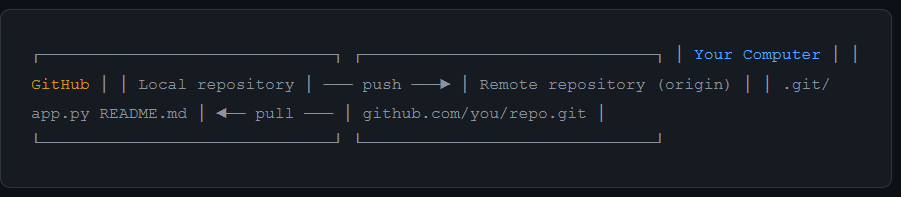 

# Scenario A -- Start a new project and push to GitHub:

1. Create a repo on GitHub Go to github.com -> click the + icon -> New Repository. Give it a name. Do NOT check "Add a README" if you already have local files.
2. Initialize your local folder:
```Python
cd my-project
git init
git add .
git commit -m "Initial commit"

```
3. Connect to GitHub and push:
```Python
# Add GitHub as the remote named "origin"

`git remote add origin https://github.com/DrChaos1999/Agentic_AI.git`
# Push your commits to GitHub(first time needs -u to set upstream)

`git push -u origin main`

Enumerating objects: 5, done.
Counting objects: 100% (5/5)
Writing objects: 100% (5/5), 1.23 KiB | 1.23 MiB/s, done.

To https://github.com/DrChaos1999/Agentic_AI.git
    * [new branch]  main->main

`Branch 'main' set up to track remote branch 'main' from 'origin'.`

```

# Scenario B -- Clone an existing GitHub repo
```Python
# Download the full repo + history to a new folder

git clone https://github.com/DrChaos1999/Agentic_AI.git

cloning into 'Agentic_AI'.....
remote: Enumerating objects: 47, done.
Receiving objects: 100% (47/47), 21.3 KiB | 2.1 MiB/s, done.

#  Enter the folder (remote is already configured)

cd Agentic_AI
git remote -v


origin  https://github.com/DrChaos1999/Agentic_AI.git (fetch)
origin  https://github.com/DrChaos1999/Agentic_AI.git (push)

```


# Managing Remotes:

```Python
# See your remotes
git remote -v

# Add a remote
git remote add origin https://github.com/you/repo.git 

# Change the remote URL (e.g. switch from HTTPS to SSH)
git remote set-url origin git@github.com:DrChaos1999/Agentic_AI.git

# Remove a remote 
git remote remove origin
```

# Push and pull in detail

```Python
# Upload your local commits to GitHub
git push origin main

# Download GitHUb commits to your local copy
git pull origin main


# Pull with unrelated histories (fixes "refusing to merge" error)
git pull origin main --allow-unrelated-histories

# Fetch (download) WITHOUT merging --safe preview

git fetch origin
git log origin/main --oneline # see what they have 
git merge origin/main  # then merge manually

```



# Common push/pull errors and fixes:

- `No such remote 'origin'` -- Remote not configured --- `git remote add origin <url>`
- `rejecte(fetch first)` -- GitHub has commits you don't--`git pull origin main` then push.
- `refusing to merge unrealted histories` -- Local and remote have separate histories -- `Add --allow-unrelated-histories`

- `Authentication failed` -- Wrong password or expired token --- Use PAT or SSH keys.

- `rejected (non-fast-forward)` --- Remote has newer commits --- Pull first, resolve conflicts, then push.


# Branching and Merging:
The feature that makes Git truly powerful. Work on multiple things simultaneously without chaos.

# What is a branch?
A branch is lightweight pointer to a specific commit. Creating a branch means you can work on a copy of your code that is completely independent of the main branch. When you are done,you merge it back.

# Creating and switching branches:

```Python
# Create a new branch and switch to it immediately 
git checkout -b feature/user-authentication

Switched to a new branch 'feature/user-authentication'

# Modern equivalent (git 2.23+)
git switch -c features/user-authentication


#List all local branches (*=curre)


# List All branches including remote ones
git branch -a 

# Switch to an existing branch
git checkout main
git switch main # modern wa